In [1]:
import xarray as xr
from matplotlib import pyplot as plt
import numpy as np
import scipy as stats
from scipy.stats import ttest_ind_from_stats

In [2]:
ds = xr.open_dataset(r"C:\Users\USER\Desktop\MA\111-2\CAD\Week6\sst.mnmean.nc")
ds
# select period 選擇時間區間
ds = ds.sel(time = slice('1960', '2018')) 
#ds

#actually load the data
ds.load()

<xarray.Dataset>
Dimensions:    (lat: 89, lon: 180, time: 708, nbnds: 2)
Coordinates:
  * lat        (lat) float32 88.0 86.0 84.0 82.0 ... -82.0 -84.0 -86.0 -88.0
  * lon        (lon) float32 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * time       (time) datetime64[ns] 1960-01-01 1960-02-01 ... 2018-12-01
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) float64 9.969e+36 9.969e+36 ... 9.969e+36 9.969e+36
    sst        (time, lat, lon) float32 -1.8 -1.8 -1.8 -1.8 ... nan nan nan nan
Attributes: (12/37)
    climatology:               Climatology is based on 1971-2000 SST, Xue, Y....
    description:               In situ data: ICOADS2.5 before 2007 and NCEP i...
    keywords_vocabulary:       NASA Global Change Master Directory (GCMD) Sci...
    keywords:                  Earth Science > Oceans > Ocean Temperature > S...
    instrument:                Conventional thermometers
    source_comment:            SSTs were observed by conventional thermometer...
    ...                        ...
    creator_url_original:      https://www.ncei.noaa.gov
    license:                   No constraints on data access or use
    comment:                   SSTs were observed by conventional thermometer...
    summary:                   ERSST.v5 is developed based on v4 after revisi...
    dataset_title:             NOAA Extended Reconstructed SST V5
    data_modified:             2023-03-04

Task 1 

In [3]:
#make anomaly
sst_clim = ds.sst.groupby('time.month').mean(dim = 'time')
sst_anom = ds.sst.groupby('time.month') - sst_clim

In [4]:
sst_clim

<xarray.DataArray 'sst' (month: 12, lat: 89, lon: 180)>
array([[[-1.8000009, -1.8000009, -1.8000009, ..., -1.8000009,
         -1.8000009, -1.8000009],
        [-1.8000009, -1.8000009, -1.8000009, ..., -1.8000009,
         -1.8000009, -1.8000009],
        [-1.8000009, -1.8000009, -1.8000009, ..., -1.8000009,
         -1.8000009, -1.8000009],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[-1.8000009, -1.8000009, -1.8000009, ..., -1.8000009,
         -1.8000009, -1.8000009],
        [-1.8000009, -1.8000009, -1.8000009, ..., -1.8000009,
         -1.8000009, -1.8000009],
        [-1.8000009, -1.8000009, -1.8000009, ..., -1.8000009,
         -1.8000009, -1.8000009],
...
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[-1.7995034, -1.7995957, -1.7998441, ..., -1.7997916,
         -1.7996523, -1.7995055],
        [-1.7995698, -1.7997586, -1.8000009, ..., -1.8000009,
         -1.7998224, -1.7996049],
        [-1.8000009, -1.8000009, -1.8000009, ..., -1.8000009,
         -1.8000009, -1.8000009],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]]], dtype=float32)
Coordinates:
  * lat      (lat) float32 88.0 86.0 84.0 82.0 80.0 ... -82.0 -84.0 -86.0 -88.0
  * lon      (lon) float32 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
  * month    (month) int64 1 2 3 4 5 6 7 8 9 10 11 12
Attributes:
    long_name:     Monthly Means of Sea Surface Temperature
    units:         degC
    var_desc:      Sea Surface Temperature
    level_desc:    Surface
    statistic:     Mean
    dataset:       NOAA Extended Reconstructed SST V5
    parent_stat:   Individual Values
    actual_range:  [-1.8     42.32636]
    valid_range:   [-1.8 45. ]

In [5]:
sst_anom

<xarray.DataArray 'sst' (time: 708, lat: 89, lon: 180)>
array([[[ 9.5367432e-07,  9.5367432e-07,  9.5367432e-07, ...,
          9.5367432e-07,  9.5367432e-07,  9.5367432e-07],
        [ 9.5367432e-07,  9.5367432e-07,  9.5367432e-07, ...,
          9.5367432e-07,  9.5367432e-07,  9.5367432e-07],
        [ 9.5367432e-07,  9.5367432e-07,  9.5367432e-07, ...,
          9.5367432e-07,  9.5367432e-07,  9.5367432e-07],
        ...,
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan]],

       [[ 9.5367432e-07,  9.5367432e-07,  9.5367432e-07, ...,
          9.5367432e-07,  9.5367432e-07,  9.5367432e-07],
        [ 9.5367432e-07,  9.5367432e-07,  9.5367432e-07, ...,
          9.5367432e-07,  9.5367432e-07,  9.5367432e-07],
        [ 9.5367432e-07,  9.5367432e-07,  9.5367432e-07, ...,
          9.5367432e-07,  9.5367432e-07,  9.5367432e-07],
...
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan]],

       [[-4.9650669e-04, -4.0423870e-04, -1.5580654e-04, ...,
         -2.0837784e-04, -3.4761429e-04, -4.9448013e-04],
        [-4.3010712e-04, -2.4139881e-04,  9.5367432e-07, ...,
          9.5367432e-07, -1.7750263e-04, -3.9505959e-04],
        [ 9.5367432e-07,  9.5367432e-07,  9.5367432e-07, ...,
          9.5367432e-07,  9.5367432e-07,  9.5367432e-07],
        ...,
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan]]], dtype=float32)
Coordinates:
  * lat      (lat) float32 88.0 86.0 84.0 82.0 80.0 ... -82.0 -84.0 -86.0 -88.0
  * lon      (lon) float32 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
  * time     (time) datetime64[ns] 1960-01-01 1960-02-01 ... 2018-12-01
    month    (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 2 3 4 5 6 7 8 9 10 11 12

In [6]:
#detrend 移掉趨勢 
#區分出variability跟trend。
from scipy.signal import detrend
sst_anom_detrended = xr.apply_ufunc(detrend, sst_anom.fillna(0),
                                    kwargs={'axis': 0}).where(~sst_anom.isnull())

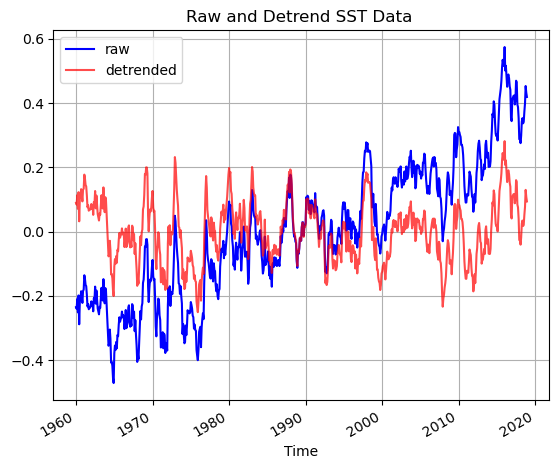

In [7]:
# For a global average, we need to weigh the points by cosine of latitude. 對緯度做出權重
# This is not built into xarray because xarray is not specific to geoscientific data.
weights = np.cos(np.deg2rad(ds.lat)).where(~sst_anom[0].isnull())
weights /= weights.mean()

(sst_anom * weights).mean(dim=['lon', 'lat']).plot(color = "blue",label='raw')
(sst_anom_detrended * weights).mean(dim=['lon', 'lat']).plot(alpha = 0.7,color = "red",label='detrended')

plt.title("Raw and Detrend SST Data ")
plt.grid()
plt.legend()

nino34

In [17]:
sst_anom_nino34 = sst_anom_detrended.sel(lat = slice(5, -5), lon = slice(190, 240)) 
sst_anom_nino34_mean = sst_anom_nino34.mean(dim = ('lon', 'lat'))
oni34 = sst_anom_nino34_mean.rolling(time = 3, center=True).mean()  
#海溫是一個long memory 的性質 #3個月的running mean，前一個timestep會影響到下一個timestep，故在物理上，此步驟是有意義的
#做每個步驟你要思考，他是有物理上的意義還是純粹美觀

nino3

In [18]:
sst_anom_nino3 = sst_anom_detrended.sel(lat=slice(5, -5), lon = slice(210, 270)) 
sst_anom_nino3_mean = sst_anom_nino3.mean(dim = ('lon', 'lat'))
oni3 = sst_anom_nino3_mean.rolling(time = 3, center=True).mean()  

nino4

In [19]:
sst_anom_nino4 = sst_anom_detrended.sel(lat=slice(5, -5), lon = slice(160, 210)) #150w 160e
sst_anom_nino4_mean = sst_anom_nino4.mean(dim = ('lon', 'lat'))
oni4 = sst_anom_nino4_mean.rolling(time = 3, center=True).mean()  

In [20]:
oni4

<xarray.DataArray 'sst' (time: 708)>
array([            nan, -1.44790471e-01, -1.12420008e-01, -1.35196550e-02,
       -1.92039609e-02, -5.02071902e-02, -1.10568993e-01, -1.31277829e-01,
       -9.63110179e-02, -6.82297349e-03,  1.57788962e-01,  2.32377574e-01,
        2.13796183e-01,  8.37262198e-02, -2.98414733e-02, -9.02453512e-02,
       -6.32318109e-02, -4.93592881e-02, -1.12365924e-01, -1.77212656e-01,
       -2.67254710e-01, -2.08502918e-01, -1.80377290e-01, -9.53672528e-02,
       -1.15800999e-01, -1.18728474e-01, -8.77494216e-02, -1.24713168e-01,
       -1.17453873e-01, -1.68502375e-01, -1.51749253e-01, -2.35743940e-01,
       -2.64412045e-01, -2.88397521e-01, -2.98066676e-01, -3.19320649e-01,
       -2.97763050e-01, -1.40911847e-01,  4.34558094e-02,  1.25199988e-01,
        4.47743982e-02,  7.20826834e-02,  2.56888449e-01,  5.46305180e-01,
        6.95493639e-01,  6.70721471e-01,  5.69992423e-01,  5.21350861e-01,
        4.63717550e-01,  2.54600763e-01,  3.05684023e-02, -1.43914104e-01,
       -2.59572983e-01, -4.17814016e-01, -6.22434735e-01, -8.44179332e-01,
       -1.02287579e+00, -1.16741633e+00, -1.15469158e+00, -9.89376485e-01,
       -6.74568355e-01, -3.90276849e-01, -3.26078236e-01, -1.95886418e-01,
        3.71023044e-02,  3.49907160e-01,  5.38526177e-01,  6.07510924e-01,
        7.62542963e-01,  8.33556175e-01,  8.82277489e-01,  8.31124783e-01,
        8.34135711e-01,  9.72510993e-01,  9.09289777e-01,  7.55486131e-01,
        5.11371493e-01,  4.89965439e-01,  4.54271793e-01,  4.02380168e-01,
...
        1.76873133e-01,  2.25322366e-01,  1.49534479e-01,  1.33669674e-02,
       -1.58166558e-01, -2.97245592e-01, -3.53550166e-01, -3.50302041e-01,
       -2.74877012e-01, -2.55313218e-01, -2.25292906e-01, -1.98233888e-01,
       -1.48084000e-01, -1.00747369e-01, -1.05401814e-01, -1.54594734e-01,
       -1.51827514e-01, -3.77779715e-02,  1.43712103e-01,  3.10363114e-01,
        3.66844654e-01,  3.07318002e-01,  2.29620516e-01,  2.31345519e-01,
        3.29602718e-01,  4.62898582e-01,  5.58295906e-01,  6.45376682e-01,
        6.88225746e-01,  7.37389505e-01,  8.19324851e-01,  8.55914474e-01,
        8.81445348e-01,  8.56818378e-01,  8.84534538e-01,  9.31409597e-01,
        9.85866904e-01,  1.11353624e+00,  1.19711661e+00,  1.24200344e+00,
        1.16515851e+00,  1.07062244e+00,  9.18380380e-01,  7.03904986e-01,
        4.89532650e-01,  2.97632724e-01,  1.14700481e-01, -9.35706124e-02,
       -2.96654582e-01, -4.46637094e-01, -4.49660122e-01, -3.60295385e-01,
       -2.47631788e-01, -1.88366979e-01, -1.07762843e-01, -1.50496769e-03,
        1.32904097e-01,  2.07732558e-01,  1.85131520e-01,  6.09899387e-02,
       -1.07296154e-01, -2.92157292e-01, -4.76087660e-01, -5.62503576e-01,
       -5.51580846e-01, -4.46992159e-01, -2.87354350e-01, -1.04366884e-01,
        7.03178495e-02,  1.52152851e-01,  2.62014866e-01,  3.72345179e-01,
        5.95580518e-01,  7.26710081e-01,  8.08586001e-01,             nan],
      dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1960-01-01 1960-02-01 ... 2018-12-01
    month    (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 2 3 4 5 6 7 8 9 10 11 12

nino1+2

In [21]:
sst_anom_nino12 = sst_anom_detrended.sel(lat=slice(0, -10), lon=slice(270, 280)) 
sst_anom_nino12_mean = sst_anom_nino12.mean(dim = ('lon', 'lat'))
oni12 = sst_anom_nino12_mean.rolling(time = 3, center=True).mean()  

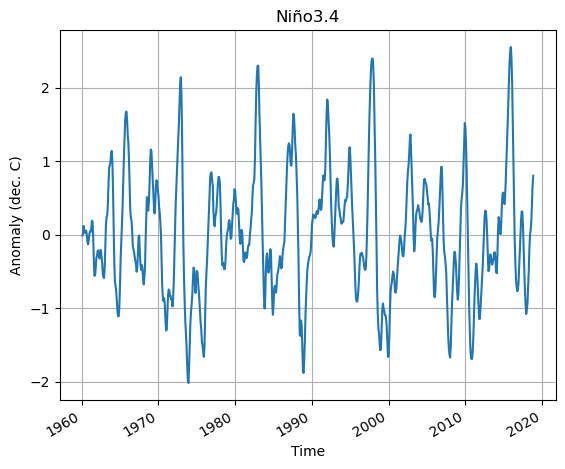

In [22]:
oni34.plot()
plt.title('Niño3.4')
plt.grid()
plt.ylabel('Anomaly (dec. C)');

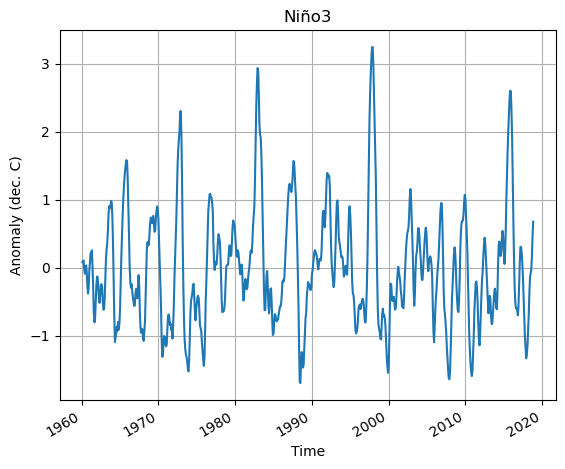

In [23]:
oni3.plot()
plt.title('Niño3')
plt.grid()
plt.ylabel('Anomaly (dec. C)');

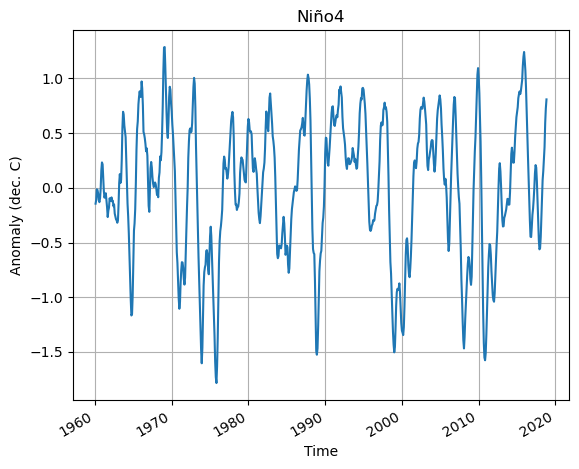

In [24]:
oni4.plot()
plt.title('Niño4')
plt.grid()
plt.ylabel('Anomaly (dec. C)');

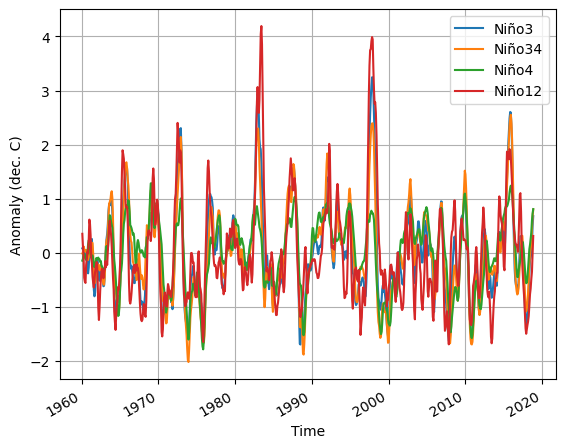

In [25]:
oni3.plot(label='Niño3')
oni34.plot(label='Niño34')
oni4.plot(label='Niño4')
oni12.plot(label='Niño12')
#plt.title('Niño3')
plt.grid()
plt.legend(loc='upper right')
plt.ylabel('Anomaly (dec. C)');

Text(0.5, 1.0, 'Niño4')

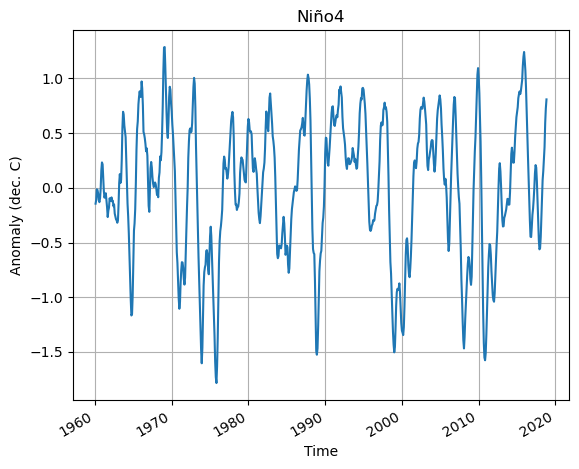

In [26]:
oni4.plot()
plt.grid()
plt.ylabel('Anomaly (dec. C)');
plt.title('Niño4')

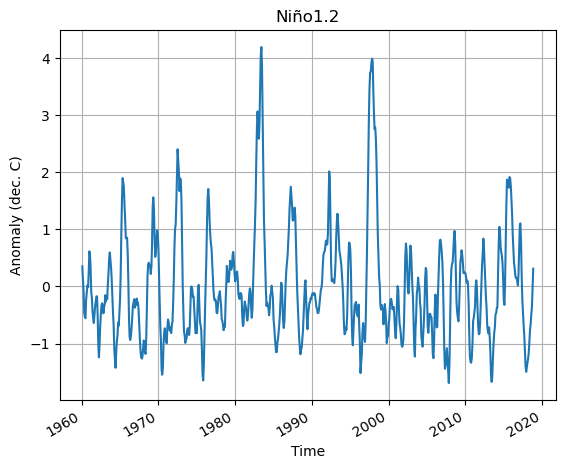

In [27]:
oni12.plot()
plt.title('Niño1.2')
plt.grid()
plt.ylabel('Anomaly (dec. C)');

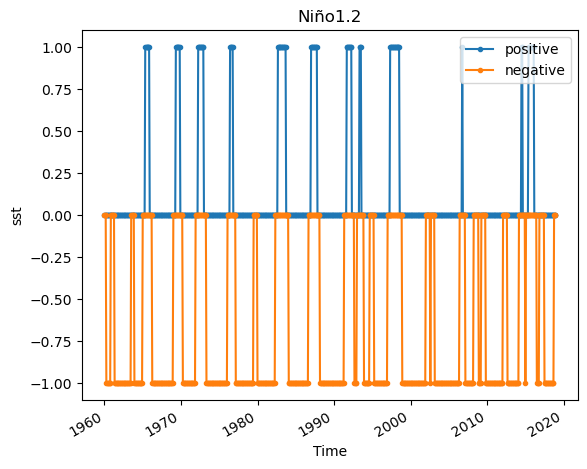

In [28]:
#oni12
positive_oni_12 = ((oni12>0.5).astype('b').rolling(time=5, center=True).sum()==5) #選出高於0.5
negative_oni_12 = ((oni12<0.5).astype('b').rolling(time=5, center=True).sum()==5) #選出低於0.5
positive_oni_12.astype('i').plot(marker='.', label='positive')
(-negative_oni_12.astype('i')).plot(marker='.', label='negative')
plt.title('Niño1.2')
plt.legend()

Text(0.5, 1.0, 'Niño3')

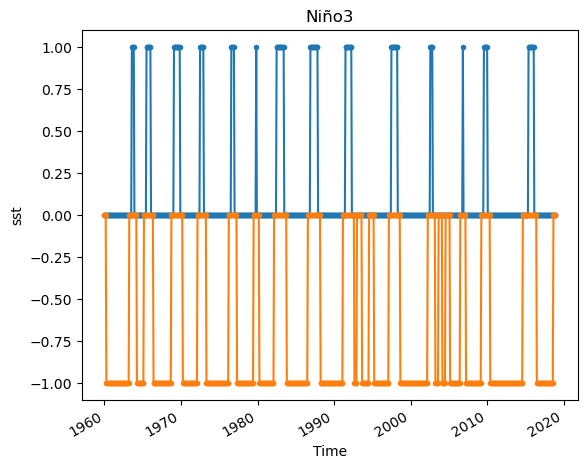

In [32]:
#oni3
positive_oni_3 = ((oni3>0.5).astype('b').rolling(time=5, center=True).sum()==5) #選出高於0.5
negative_oni_3 = ((oni3<0.5).astype('b').rolling(time=5, center=True).sum()==5) #選出低於0.5
positive_oni_3.astype('i').plot(marker='.', label='positive')
(-negative_oni_3.astype('i')).plot(marker='.', label='negative')
plt.title('Niño3')
#plt.legend()

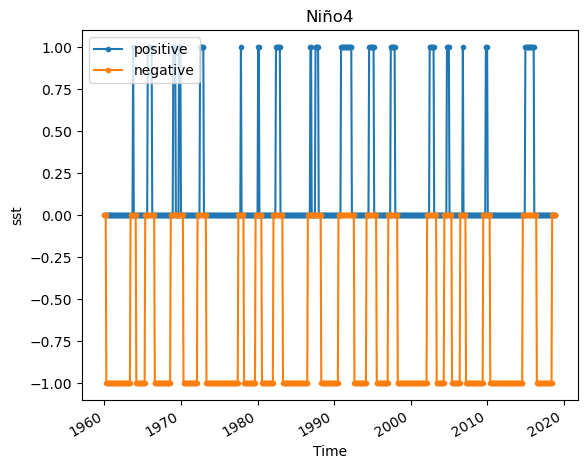

In [30]:
#oni4
positive_oni_4 = ((oni4>0.5).astype('b').rolling(time=5, center=True).sum()==5) #選出高於0.5
negative_oni_4 = ((oni4<0.5).astype('b').rolling(time=5, center=True).sum()==5) #選出低於0.5
positive_oni_4.astype('i').plot(marker='.', label='positive')
(-negative_oni_4.astype('i')).plot(marker='.', label='negative')
plt.title('Niño4')
plt.legend()

Text(0.5, 1.0, 'Niño3.4')

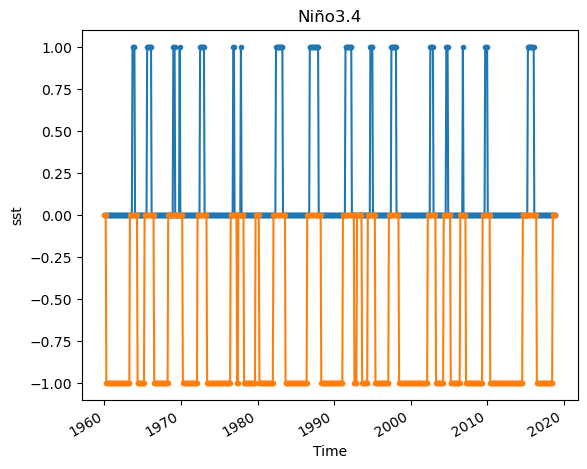

In [31]:
positive_oni_34 = ((oni34>0.5).astype('b').rolling(time=5, center=True).sum()==5) #選出高於0.5
negative_oni_34 = ((oni34<0.5).astype('b').rolling(time=5, center=True).sum()==5) #選出低於0.5
positive_oni_34.astype('i').plot(marker='.', label='positive')
(-negative_oni_34.astype('i')).plot(marker='.', label='negative')
plt.title('Niño3.4')
#plt.legend()

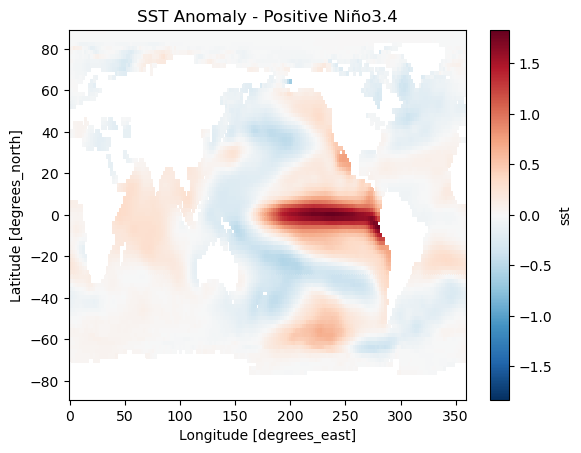

In [25]:
sst_anom.where(positive_oni_34).mean(dim='time').plot()
plt.title('SST Anomaly - Positive Niño3.4');

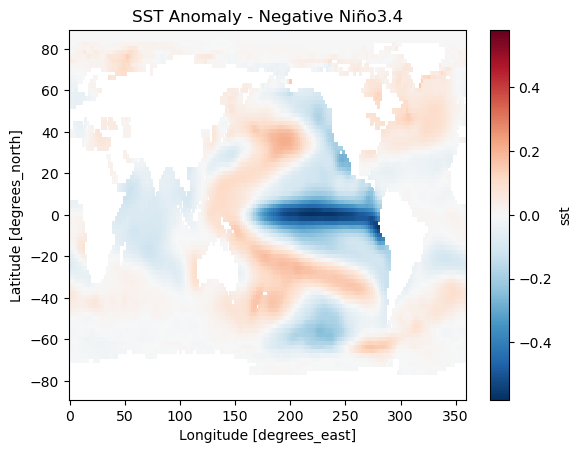

In [27]:
sst_anom.where(negative_oni_34).mean(dim='time').plot()
plt.title('SST Anomaly - Negative Niño3.4');

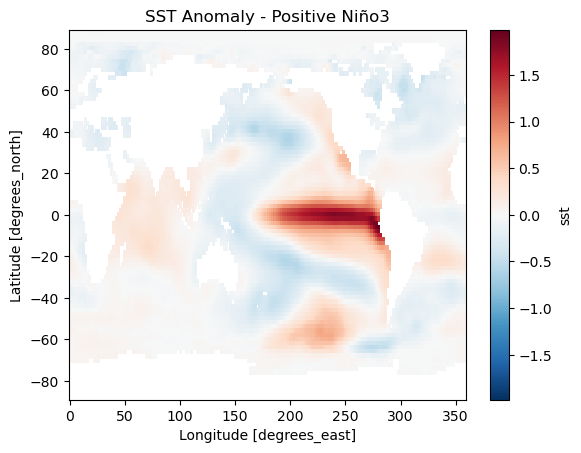

In [68]:
sst_anom.where(positive_oni_3).mean(dim='time').plot()
plt.title('SST Anomaly - Positive Niño3');

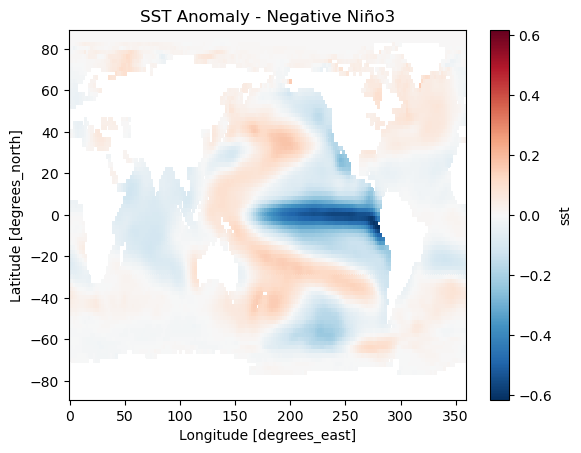

In [69]:
sst_anom.where(negative_oni_3).mean(dim='time').plot()
plt.title('SST Anomaly - Negative Niño3');

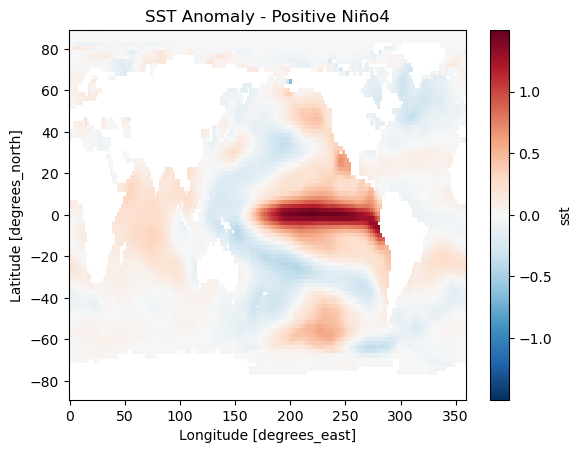

In [71]:
sst_anom.where(positive_oni_4).mean(dim='time').plot()
plt.title('SST Anomaly - Positive Niño4');


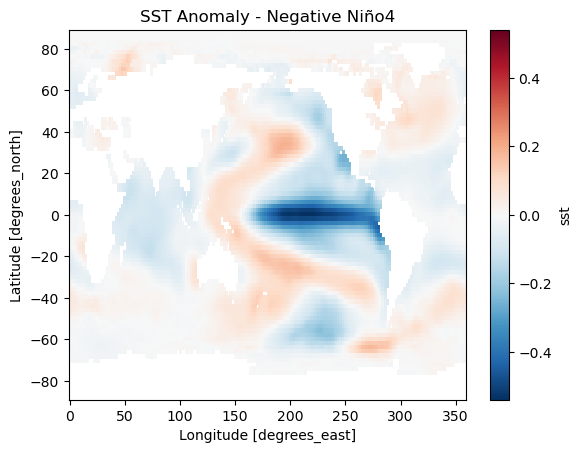

In [72]:
sst_anom.where(negative_oni_4).mean(dim='time').plot()
plt.title('SST Anomaly - Negative Niño4');

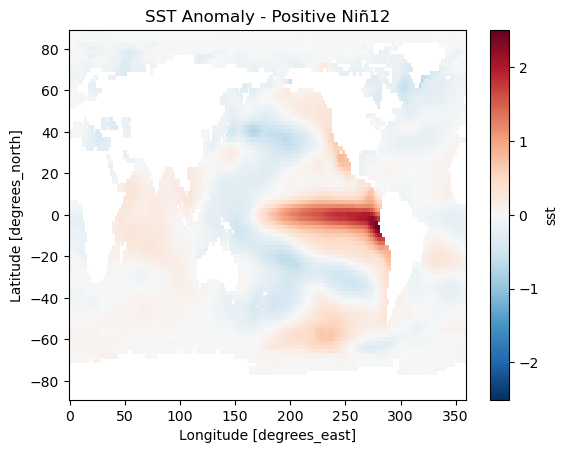

In [73]:
sst_anom.where(positive_oni_12).mean(dim='time').plot()
plt.title('SST Anomaly - Positive Niñ12');


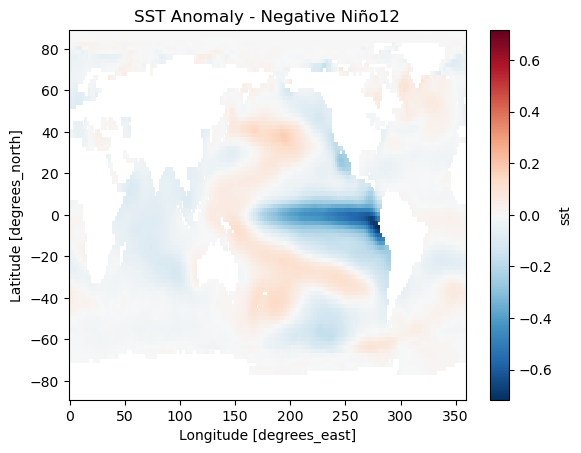

In [74]:
sst_anom.where(negative_oni_12).mean(dim='time').plot()
plt.title('SST Anomaly - Negative Niño12');

Add sifnificant t test

In [87]:
mean1 = sst_anom.where(positive_oni_3).mean(dim='time')  #正年所有年
mean2 = sst_anom.mean(dim='time')               #所有年

#mean1.plot()
#mean2.plot()

In [88]:
std1 = sst_anom.where(positive_oni_3).std(dim='time')
#std1.plot()
std2 = sst_anom.std(dim='time')
#std2.plot()

In [89]:
nobs1 = np.count_nonzero(positive_oni_3)   #選出不等於0的個數
#nobs1
nobs2 = len(oni3) #全部年的各數
#nobs2

In [90]:
modified_std1 = np.sqrt(np.float32(nobs1)/np.float32(nobs1-1)) * std1
#modified_std1
modified_std2 = np.sqrt(np.float32(nobs2)/np.float32(nobs2-1)) * std2
#modified_std2

In [91]:
import scipy.stats as stats
from scipy.stats import ttest_ind, ttest_ind_from_stats

In [92]:
(statistic, pvalue) = stats.ttest_ind_from_stats(mean1=mean1, std1=modified_std1, nobs1=nobs1, mean2=mean2, std2=modified_std2, nobs2=nobs2 )
print(pvalue)

[[0.46643093 0.4915203  0.50604445 ... 0.43450817 0.43971732 0.4447678 ]
 [0.50142205 0.5103219  0.5193409  ... 0.5193356  0.5079857  0.49964115]
 [0.5805186  0.5193376  0.5193355  ... 0.5769379  0.58062434 0.58063555]
 ...
 [       nan        nan        nan ...        nan        nan        nan]
 [       nan        nan        nan ...        nan        nan        nan]
 [       nan        nan        nan ...        nan        nan        nan]]


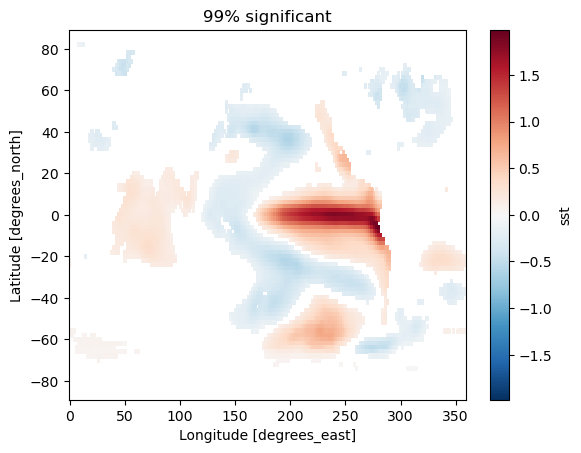

In [94]:
alpha = 0.01 #95信心水準
mean1_sig=mean1.where(pvalue <= alpha) #只畫有過檢定的地方，沒過的就濾掉
mean1_sig.plot()
plt.title('99% significant');

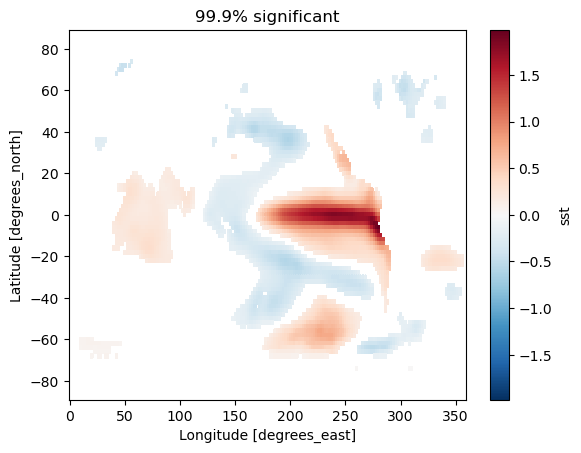

In [95]:
alpha = 0.001 #95信心水準
mean1_sig=mean1.where(pvalue <= alpha) #只畫有過檢定的地方，沒過的就濾掉
mean1_sig.plot()
plt.title('99.9% significant');

In [35]:
mean1_sig.to_netcdf(path="Elnino_sig.nc")
mean1.to_netcdf(path="Elnino_nosig.nc")

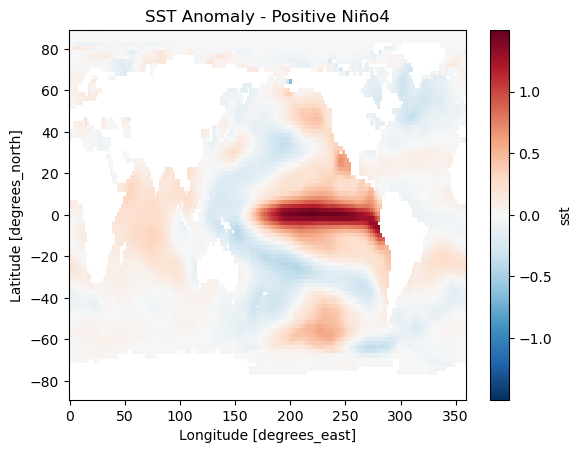

In [36]:
sst_anom.where(positive_oni_4).mean(dim='time').plot()
plt.title('SST Anomaly - Positive Niño4');

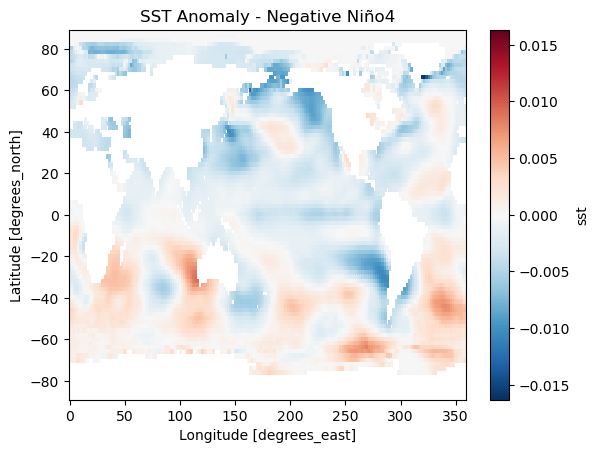

In [34]:
sst_anom.where(negative_oni_4).mean(dim='time').plot()
plt.title('SST Anomaly - Negative Niño4');

Task2

In [37]:
ds_prec = xr.open_dataset(r"C:\Users\USER\Desktop\MA\111-2\CAD\Week5\precip.mon.mean.nc")
ds_prec = ds_prec.sel(time = slice('1960', '2018')) 
ds_prec.load()

<xarray.Dataset>
Dimensions:    (lat: 72, lon: 144, time: 480, nv: 2)
Coordinates:
  * lat        (lat) float32 -88.75 -86.25 -83.75 -81.25 ... 83.75 86.25 88.75
  * lon        (lon) float32 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
  * time       (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2018-12-01
Dimensions without coordinates: nv
Data variables:
    time_bnds  (time, nv) datetime64[ns] 1979-01-01 1979-02-01 ... 2019-01-01
    lat_bnds   (lat, nv) float32 -90.0 -87.5 -87.5 -85.0 ... 85.0 87.5 87.5 90.0
    lon_bnds   (lon, nv) float32 0.0 2.5 2.5 5.0 5.0 ... 355.0 357.5 357.5 360.0
    precip     (time, lat, lon) float32 0.0 0.0 0.0 0.0 ... 0.1616 0.1712 0.1766
Attributes: (12/18)
    Conventions:           CF-1.0
    curator:               Dr. Jian-Jian Wang\nESSIC, University of Maryland ...
    citation:              Adler, R.F., G.J. Huffman, A. Chang, R. Ferraro, P...
    title:                 GPCP Version 2.3 Combined Precipitation Dataset (F...
    platform:              NOAA POES (Polar Orbiting Environmental Satellites)
    source_obs:            CDR RSS SSMI/SSMIS Tbs over ocean \nCDR SSMI/SSMIS...
    ...                    ...
    source:                https://www.ncei.noaa.gov/data/global-precipitatio...
    source_documentation:  https://www.ncdc.noaa.gov/cdr/atmospheric/precipit...
    NCO:                   4.6.9
    history:               Generated at NOAA/ESRL PSD Sep 9 2016 based on dat...
    References:            http://www.psl.noaa.gov/data/gridded/data.gpcp.html
    data_comment:          Interim data covers 2023/01 through latest.

precip anomoly

In [39]:
#make anomaly
prec_clim = ds_prec.precip.groupby('time.month').mean(dim = 'time')
prec_anom = ds_prec.precip.groupby('time.month') - prec_clim

In [40]:
from scipy.signal import detrend
prec_anom_detrended = xr.apply_ufunc(detrend, prec_anom.fillna(0),
                                    kwargs={'axis': 0}).where(~prec_anom.isnull())

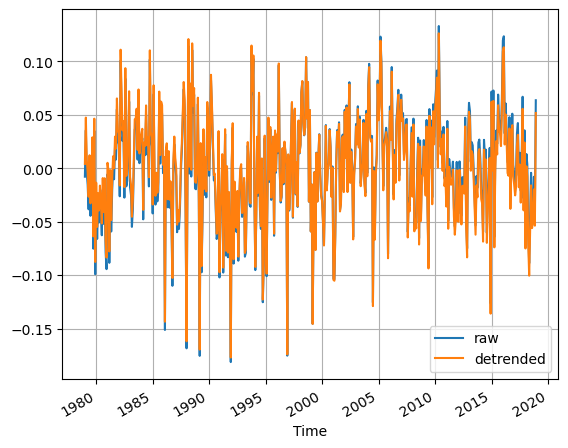

In [41]:
# For a global average, we need to weigh the points by cosine of latitude. 對緯度做出權重
# This is not built into xarray because xarray is not specific to geoscientific data.
weights = np.cos(np.deg2rad(ds_prec.lat)).where(~prec_anom[0].isnull())
weights /= weights.mean()

(prec_anom * weights).mean(dim=['lon', 'lat']).plot(label='raw')
(prec_anom_detrended * weights).mean(dim=['lon', 'lat']).plot(label = 'detrended')


plt.grid()
plt.legend()

mslp anomoly

In [57]:
ds_mslp = xr.open_dataset(r"C:\Users\USER\Desktop\MA\111-2\CAD\Week5\mslp.mon.mean.nc")
ds_mslp = ds_mslp.sel(time = slice('1960', '2018')) 
ds_mslp.load()

<xarray.Dataset>
Dimensions:    (lat: 73, lon: 144, time: 480, nbnds: 2)
Coordinates:
  * lat        (lat) float32 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
  * lon        (lon) float32 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time       (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2018-12-01
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) datetime64[ns] 1979-01-01 1979-02-01 ... 2019-01-01
    mslp       (time, lat, lon) float32 1.022e+05 1.022e+05 ... 9.974e+04
Attributes:
    Conventions:    CF-1.0
    title:          Monthly NCEP/DOE Reanalysis 2
    comments:       Data is from \nNCEP/DOE AMIP-II Reanalysis (Reanalysis-2)...
    platform:       Model
    source:         NCEP/DOE AMIP-II Reanalysis (Reanalysis-2) Model
    institution:    National Centers for Environmental Prediction
    dataset_title:  NCEP-DOE AMIP-II Reanalysis
    References:     https://www.psl.noaa.gov/data/gridded/data.ncep.reanalysi...
    source_url:     http://www.cpc.ncep.noaa.gov/products/wesley/reanalysis2/
    history:        created 2002/03 by Hoop (netCDF2.3)\nConverted to chunked...

In [58]:
#make anomaly
mslp_clim = ds_mslp.groupby('time.month').mean(dim = 'time')
mslp_anom = ds_mslp.groupby('time.month') - mslp_clim

In [59]:
from scipy.signal import detrend
mslp_anom_detrended = xr.apply_ufunc(detrend, mslp_anom.fillna(0),
                                    kwargs={'axis': 0}).where(~mslp_anom.isnull())

In [60]:
mslp_anom_detrended

<xarray.Dataset>
Dimensions:  (time: 480, lat: 73, lon: 144)
Coordinates:
  * lat      (lat) float32 90.0 87.5 85.0 82.5 80.0 ... -82.5 -85.0 -87.5 -90.0
  * lon      (lon) float32 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time     (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2018-12-01
    month    (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    mslp     (time, lat, lon) float32 866.2 866.2 866.2 ... -274.1 -274.1 -274.1

In [61]:
weights = np.cos(np.deg2rad(ds_mslp.lat)).where(~mslp_anom[0].isnull())
weights /= weights.mean()

(mslp_anom * weights).mean(dim=['lon', 'lat']).plot(label='raw')
(mslp_anom_detrended * weights).mean(dim=['lon', 'lat']).plot(label = 'detrended')


plt.grid()
plt.legend()

KeyError: 0

In [63]:
ur3 = 'http://www.esrl.noaa.gov/psd/thredds/dodsC/Datasets/ncep.reanalysis2.derived/surface/mslp.mon.mean.nc'
mslp2 = xr.open_dataset(ur3)
print(mslp2)
#ds

# select period
mslp2 = mslp2.sel(time=slice('1960', '2018'))
#ds

#actually load the data
mslp2.load()

<xarray.Dataset>
Dimensions:    (lat: 73, lon: 144, time: 530, nbnds: 2)
Coordinates:
  * lat        (lat) float32 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
  * lon        (lon) float32 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time       (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2023-02-01
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) datetime64[ns] ...
    mslp       (time, lat, lon) float32 ...
Attributes:
    Conventions:                     CF-1.0
    title:                           Monthly NCEP/DOE Reanalysis 2
    comments:                        Data is from \nNCEP/DOE AMIP-II Reanalys...
    platform:                        Model
    source:                          NCEP/DOE AMIP-II Reanalysis (Reanalysis-...
    institution:                     National Centers for Environmental Predi...
    dataset_title:                   NCEP-DOE AMIP-II Reanalysis
    References:                      https://www.psl.noaa.gov/dat

<xarray.Dataset>
Dimensions:    (lat: 73, lon: 144, time: 480, nbnds: 2)
Coordinates:
  * lat        (lat) float32 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
  * lon        (lon) float32 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time       (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2018-12-01
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) datetime64[ns] 1979-01-01 1979-02-01 ... 2019-01-01
    mslp       (time, lat, lon) float32 1.022e+05 1.022e+05 ... 9.974e+04
Attributes:
    Conventions:                     CF-1.0
    title:                           Monthly NCEP/DOE Reanalysis 2
    comments:                        Data is from \nNCEP/DOE AMIP-II Reanalys...
    platform:                        Model
    source:                          NCEP/DOE AMIP-II Reanalysis (Reanalysis-...
    institution:                     National Centers for Environmental Predi...
    dataset_title:                   NCEP-DOE AMIP-II Reanalysis
    References:                      https://www.psl.noaa.gov/data/gridded/da...
    source_url:                      http://www.cpc.ncep.noaa.gov/products/we...
    _NCProperties:                   version=2,netcdf=4.7.3,hdf5=1.10.6,
    history:                         created 2002/03 by Hoop (netCDF2.3)\nCon...
    DODS_EXTRA.Unlimited_Dimension:  time

In [64]:
#make anomaly
mslp_clim2 = mslp2.groupby('time.month').mean(dim = 'time')
mslp_anom2 = mslp2.groupby('time.month') - mslp_clim

In [65]:
from scipy.signal import detrend
mslp_anom2_detrended = xr.apply_ufunc(detrend, mslp_anom2.fillna(0),
                                    kwargs={'axis': 0}).where(~mslp_anom2.isnull())

In [67]:
weights = np.cos(np.deg2rad(ds_mslp.lat)).where(~mslp_anom2[0].isnull())
weights /= weights.mean()

(mslp_anom2 * weights).mean(dim=['lon', 'lat']).plot(label='raw')
(mslp_anom2_detrended * weights).mean(dim=['lon', 'lat']).plot(label = 'detrended')


plt.grid()
plt.legend()

KeyError: 0